# Call Labeling Benchmark, part 1: exploring ABCD

**Question for the full benchmark:** can a System One decision model (Jev, Laya) label customer-service conversations as well as frontier LLMs and a supervised baseline, and at what cost and latency?

**This notebook** only looks at the data, before any label or model is chosen. No model is trained or tuned here. One caveat: the recoverability check in section 7 counts keywords across all splits, test included, and the keyword baseline in the benchmark reuses those keywords, so that baseline is exploratory rather than a clean holdout.

**Dataset:** ABCD, the Action-Based Conversations Dataset (ASAPP, NAACL 2021), MIT license. About 10k customer-service conversations where agents follow company policy and click system actions (verify identity, offer refund, notify a team...). The conversations are role-played chat, not recorded calls: the real call-center corpora are all non-commercial. The principle being tested is labeling conversations, not the realness of the set.

**Sections:** 1 Load, 2 Anatomy of one conversation, 3 Length, 4 Call reason labels, 5 Action labels, 6 The policy trap, 7 Leakage and recoverability, 8 Candidate questions.

## 1. Load

Pulled straight from the official GitHub repo at a pinned commit and cached outside the repo, so no data file is ever committed.

In [1]:
import gzip
import json
import re
import urllib.request
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import tiktoken

ABCD_COMMIT = "6b8700ce67c6b37b062dd7a60abc76d7ef832a97"   # asappresearch/abcd, pinned
ABCD_FILES = ["data/abcd_v1.1.json.gz", "data/kb.json", "data/ontology.json"]
CACHE_DIR = Path.home() / ".cache" / "abcd" / ABCD_COMMIT

for file in ABCD_FILES:
    local_path = CACHE_DIR / file
    if not local_path.exists():
        local_path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/asappresearch/abcd/{ABCD_COMMIT}/{file}", local_path)

with gzip.open(CACHE_DIR / "data/abcd_v1.1.json.gz") as f:
    abcd = json.load(f)
policy_actions = json.loads((CACHE_DIR / "data/kb.json").read_text())      # subflow -> actions the policy calls for
ontology = json.loads((CACHE_DIR / "data/ontology.json").read_text())

print({split: len(conversations) for split, conversations in abcd.items()})

{'train': 8034, 'dev': 1004, 'test': 1004}


## 2. Anatomy of one conversation

Each conversation has three kinds of lines: **agent**, **customer**, and **action**. Action lines are the agent's button clicks in the company system, logged with a structured name (`verify-identity`, `offer-refund`, ...). Every conversation also carries a **scenario**: the customer's profile, their order, and the hidden reason for contact (`flow` / `subflow`).

The delexed version stores the structured action name for each action line; the original version keeps the real names and numbers. We use the original text and take action names from the delexed copy.

In [2]:
sample = abcd["train"][0]
print("Reason for contact:", sample["scenario"]["flow"], "/", sample["scenario"]["subflow"], "\n")
for (speaker, text), delexed_turn in zip(sample["original"], sample["delexed"]):
    action_name = f"   <- {delexed_turn['targets'][2]}" if speaker == "action" else ""
    print(f"{speaker:>8}: {text}{action_name}")

Reason for contact: product_defect / return_size 

   agent: Hi!
   agent: How can I help you?
customer: Hi! I need to return an item, can you help me with that?
   agent: sure, may I have your name please?
customer: Crystal Minh
   agent: thanks, may I ask the reason for the return?
  action: Account has been pulled up for Crystal Minh.   <- pull-up-account
customer: I got the wrong size.
   agent: ok, may I have your username, email address and order ID please?
customer: Username: cminh730
customer: cminh730@email.com
customer: Order ID: 3348917502
  action: Purchase validation in progress ...   <- validate-purchase
   agent: thanks so much! What is your membership level Crystal?
customer: I'm a bronze
   agent: ok, was the purchase made in the last 90 days?
customer: No, I bought it in November.
   agent: ok, unfortunately because it has been more than 90 days we cannot accept the return. Would there be anything else I can help you with?
customer: What if I ask really, really nicely

### One row per conversation

The transcript every model will see keeps only **agent and customer lines**. Action lines are dropped (they would hand over the answer, see section 7).

In [3]:
token_encoder = tiktoken.get_encoding("o200k_base")   # GPT-family tokenizer, a rough cross-vendor yardstick

def conversation_text(conversation):
    return "\n".join(f"{speaker.capitalize()}: {text}" for speaker, text in conversation["original"] if speaker != "action")

rows = []
for split, conversations in abcd.items():
    for conversation in conversations:
        actions = [turn["targets"][2] for turn in conversation["delexed"] if turn["speaker"] == "action"]
        notified_teams = [" ".join(turn["targets"][3]) for turn in conversation["delexed"]
                          if turn["speaker"] == "action" and turn["targets"][2] == "notify-team"]
        text = conversation_text(conversation)
        rows.append({
            "split": split,
            "convo_id": conversation["convo_id"],
            "flow": conversation["scenario"]["flow"],
            "subflow": conversation["scenario"]["subflow"],
            "member_level": conversation["scenario"]["personal"]["member_level"],
            "turns": sum(speaker != "action" for speaker, _ in conversation["original"]),
            "actions": actions,
            "notified_teams": notified_teams,
            "tokens": len(token_encoder.encode(text)),
            "text": text,
        })
conversations = pd.DataFrame(rows)
conversations.drop(columns=["text"]).head()

,split,convo_id,flow,subflow,member_level,turns,actions,notified_teams,tokens
0,train,3592,product_defect,return_size,bronze,25,"[pull-up-account, validate-purchase, enter-det...",[manager],290
1,train,9489,product_defect,refund_status,gold,19,"[pull-up-account, validate-purchase]",[],179
2,train,3695,storewide_query,timing_4,bronze,19,"[search-faq, search-timing, select-faq]",[],216
3,train,5798,shipping_issue,manage,silver,19,"[pull-up-account, shipping-status, validate-pu...",[],202
4,train,3647,storewide_query,pricing_3,guest,20,"[search-faq, search-pricing, select-faq]",[],235


## 3. Length

Short conversations matter for two contenders: Laya's English checkpoint reads at most **512 tokens** (ModernBERT tokenizer) and the question text shares that budget. Jev's 32k state limit is not a constraint here.

In [4]:
try:
    from transformers import AutoTokenizer
    modernbert_tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-large")
    conversations["modernbert_tokens"] = [len(modernbert_tokenizer(text)["input_ids"]) for text in conversations["text"]]
except Exception as error:   # the tokenizer download is optional for exploring
    print("ModernBERT tokenizer unavailable:", error)

length_columns = [column for column in ["turns", "tokens", "modernbert_tokens"] if column in conversations]
print(conversations[length_columns].describe(percentiles=[0.5, 0.9, 0.99]).round(0).to_string())
if "modernbert_tokens" in conversations:
    for budget in [512, 400, 1024]:
        print(f"fits in {budget} ModernBERT tokens: {(conversations['modernbert_tokens'] <= budget).mean():.1%}")

C:\Users\miste\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


         turns   tokens  modernbert_tokens
count  10042.0  10042.0            10042.0
mean      18.0    228.0              245.0
std        7.0     81.0               86.0
min        4.0     49.0               54.0
50%       17.0    216.0              232.0
90%       27.0    333.0              356.0
99%       39.0    484.0              516.0
max       69.0    872.0              900.0
fits in 512 ModernBERT tokens: 98.9%
fits in 400 ModernBERT tokens: 94.8%
fits in 1024 ModernBERT tokens: 100.0%


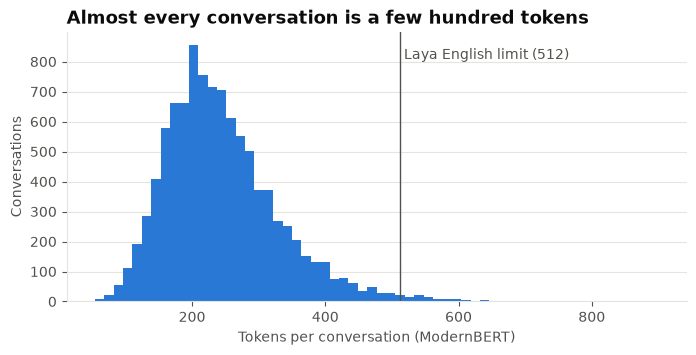

saved figures\01_conversation_length.png


In [5]:
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
INK, MUTED_INK, GRID, SURFACE, LEAD = "#0b0b0b", "#52514e", "#e5e4df", "#ffffff", "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED_INK, "xtick.color": MUTED_INK, "ytick.color": MUTED_INK,
    "text.color": INK, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10, "legend.frameon": False,
})

def style_value_axis(ax, axis="y"):
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def save_figure(fig, name):
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"saved {path}")

length_column = "modernbert_tokens" if "modernbert_tokens" in conversations else "tokens"
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(conversations[length_column], bins=60, color=LEAD)
ax.axvline(512, color=MUTED_INK, linewidth=1)
ax.text(518, ax.get_ylim()[1] * 0.9, "Laya English limit (512)", color=MUTED_INK)
ax.set_title("Almost every conversation is a few hundred tokens")
ax.set_xlabel("Tokens per conversation (" + ("ModernBERT" if length_column == "modernbert_tokens" else "o200k") + ")")
ax.set_ylabel("Conversations")
style_value_axis(ax)
save_figure(fig, "01_conversation_length")

## 4. Call reason labels

Two levels of ground truth, both taken from the scenario the customer was given:
- **flow**: 10 broad reasons for contact
- **subflow**: the specific intent. ABCD defines 55 intents, each with a policy entry in `kb.json`. For the two FAQ flows the scenario stores the specific FAQ article instead (`boots_how_2`, `timing_1`), which belongs to the intent named before the article number (`boots`, `timing`).

In [6]:
faq_flows = {"single_item_query", "storewide_query"}
conversations["intent"] = [subflow.split("_")[0] if flow in faq_flows else subflow
                           for flow, subflow in zip(conversations["flow"], conversations["subflow"])]
print("flows:", conversations["flow"].nunique(), "| raw subflows incl. FAQ articles:", conversations["subflow"].nunique(),
      "| intents:", conversations["intent"].nunique(), "| intents with a policy entry:", len(policy_actions))
off_ontology = conversations.loc[~conversations["intent"].isin(policy_actions), ["split", "convo_id", "intent"]]
print("conversations whose intent is missing from the ontology (dropped in the benchmark):", off_ontology.to_dict("records"))
print(pd.crosstab(conversations["flow"], conversations["split"]).assign(intents=conversations.groupby("flow")["intent"].nunique()).to_string())

flows: 10 | raw subflows incl. FAQ articles: 96 | intents: 56 | intents with a policy entry: 55
conversations whose intent is missing from the ontology (dropped in the benchmark): [{'split': 'train', 'convo_id': 1227, 'intent': 'status_questions'}, {'split': 'train', 'convo_id': 775, 'intent': 'status_questions'}, {'split': 'train', 'convo_id': 1383, 'intent': 'status_questions'}, {'split': 'train', 'convo_id': 941, 'intent': 'status_questions'}, {'split': 'train', 'convo_id': 1327, 'intent': 'status_questions'}, {'split': 'train', 'convo_id': 349, 'intent': 'status_questions'}, {'split': 'train', 'convo_id': 162, 'intent': 'status_questions'}, {'split': 'train', 'convo_id': 1372, 'intent': 'status_questions'}, {'split': 'train', 'convo_id': 713, 'intent': 'status_questions'}, {'split': 'train', 'convo_id': 200, 'intent': 'status_questions'}, {'split': 'train', 'convo_id': 274, 'intent': 'status_delivery_date'}, {'split': 'train', 'convo_id': 317, 'intent': 'status_questions'}, {'split

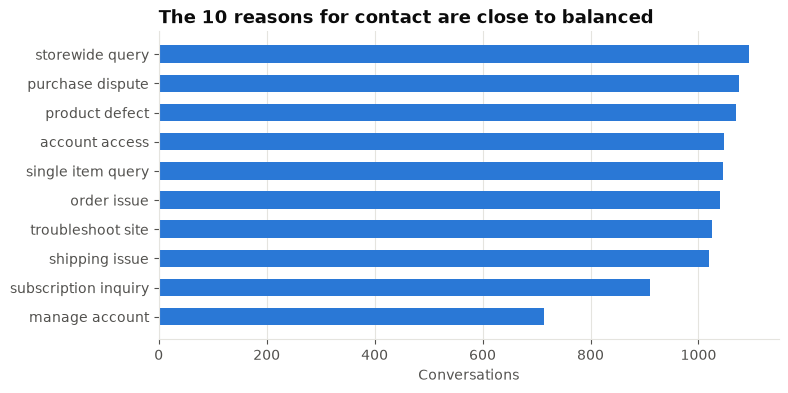

saved figures\02_call_reasons.png


In [7]:
flow_counts = conversations["flow"].value_counts()[::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(flow_counts.index.str.replace("_", " "), flow_counts.values, height=0.6, color=LEAD)
ax.set_title("The 10 reasons for contact are close to balanced")
ax.set_xlabel("Conversations")
style_value_axis(ax, "x")
save_figure(fig, "02_call_reasons")

## 5. Action labels

Actions record what the agent actually **did**, logged by the system rather than judged by an annotator. That makes them objective yes/no labels for outcome and quality-assurance questions.

In [8]:
action_presence = Counter(action for actions in conversations["actions"] for action in set(actions))
action_table = pd.DataFrame({"conversations": pd.Series(action_presence)})
action_table["share"] = (action_table["conversations"] / len(conversations)).round(3)
action_table["test positives"] = pd.Series(Counter(
    action for actions in conversations.loc[conversations["split"] == "test", "actions"] for action in set(actions)))
print(action_table.sort_values("conversations", ascending=False).to_string())
print("\nnotify-team targets:", Counter(team for teams in conversations["notified_teams"] for team in teams).most_common(8))

                     conversations  share  test positives
pull-up-account               6936  0.691             691
verify-identity               3379  0.336             345
search-faq                    2341  0.233             233
validate-purchase             2273  0.226             216
enter-details                 2005  0.200             200
ask-the-oracle                1696  0.169             163
select-faq                    1579  0.157             159
record-reason                 1546  0.154             163
update-order                  1512  0.151             134
membership                    1371  0.137             133
log-out-in                     892  0.089              92
shipping-status                882  0.088              78
offer-refund                   788  0.078              68
send-link                      745  0.074              56
update-account                 714  0.071              90
try-again                      704  0.070              58
subscription-s

## 6. The policy trap

`kb.json` lists the actions each intent's policy calls for. It is tempting to label a conversation "non-compliant" when an action is missing. The numbers below show why that would be a bad label: most "missing" actions are policy **branches**, not mistakes. Example from section 2: the return was denied because the purchase was over 90 days old, so no refund was offered, correctly.

So compliance can't be read off `kb.json` mechanically. Action presence can.

In [9]:
covered = conversations[conversations["subflow"].isin(policy_actions)].copy()   # FAQ articles have FAQ steps, not account actions
covered["all_policy_actions_done"] = [set(policy_actions[subflow]) <= set(actions)
                                      for subflow, actions in zip(covered["subflow"], covered["actions"])]
print(f"conversations with a policy entry: {len(covered):,}; every listed action performed: {covered['all_policy_actions_done'].mean():.1%}\n")

audit = []
for action in ["verify-identity", "offer-refund", "promo-code", "notify-team", "update-order", "update-account"]:
    listed = covered["subflow"].map(lambda subflow: action in policy_actions[subflow])
    done = covered["actions"].map(lambda actions: action in actions)
    audit.append({"action": action, "listed & done": int((listed & done).sum()),
                  "listed & missing": int((listed & ~done).sum()), "not listed & done": int((~listed & done).sum())})
pd.DataFrame(audit).set_index("action")

conversations with a policy entry: 7,870; every listed action performed: 37.6%


,listed & done,listed & missing,not listed & done
action,,,
verify-identity,2820,200,497
offer-refund,684,491,102
promo-code,534,253,22
notify-team,442,513,106
update-order,1386,1270,119
update-account,485,310,210


## 7. Leakage and recoverability

**Leakage.** Action lines state the answer outright ("A refund has been made...", "Membership level of Gold"). They are removed from every transcript a model sees; the check below confirms no action text survives.

**Recoverability.** With the action lines gone, a label is only fair if the conversation itself shows it. A crude keyword check gives a first read: how often a keyword appears when the action happened vs when it didn't. High on both sides = the keyword is ambiguous and the model has to read. Low when the action happened = the label may not be visible in the text at all, and those rows need a hand audit before they count as ground truth.

**Result:** refund, promo and team-handoff are almost fully recoverable, and a single regex already separates them well (notify-team: 97% vs 2%). That cuts both ways: the labels are fair, but a **keyword baseline** must be in the lineup, or a model can look smart for doing what `grep` does. The interesting rows are the ~10% where "refund" is mentioned but none was given (denied, asked about, already processed). `update-order` is the opposite: often invisible to keywords, and a candidate for a hand audit.

In [10]:
# Phrases that only appear in system action lines. Any hit in a kept line is printed so it can be judged by eye.
ACTION_LINE_PHRASES = ("has been pulled up for", "in progress ...", "in progess ...")
for convo_id, text in zip(conversations["convo_id"], conversations["text"]):
    for line in text.splitlines():
        if any(phrase in line for phrase in ACTION_LINE_PHRASES):
            print(f"convo {convo_id}: {line}")   # expected: one customer quoting the UI, not a leaked action line

KEYWORDS = {
    "offer-refund": r"\brefund",
    "promo-code": r"\bpromo|\bcode\b|discount",
    "notify-team": r"manager|supervisor|department|team|escalat",
    "verify-identity": r"verif|zip ?code|account id",
    "update-order": r"\bupdat|\bchang|\bcancel",
}
recoverability = []
for action, pattern in KEYWORDS.items():
    has_action = conversations["actions"].map(lambda actions: action in actions)
    mentions = conversations["text"].str.contains(pattern, flags=re.IGNORECASE, regex=True)
    recoverability.append({"action": action, "prevalence": has_action.mean(),
                           "keyword | action happened": mentions[has_action].mean(),
                           "keyword | didn't happen": mentions[~has_action].mean()})
pd.DataFrame(recoverability).set_index("action").round(3)

convo 148: Customer: it says "account has been pulled up for ." just a period


,prevalence,keyword | action happened,keyword | didn't happen
action,,,
offer-refund,0.078,0.933,0.097
promo-code,0.057,0.986,0.131
notify-team,0.056,0.974,0.019
verify-identity,0.336,0.930,0.270
update-order,0.151,0.396,0.193


### Contamination

ABCD has been public since 2021, so frontier LLMs may have seen it. It is far less famous than MultiWOZ, and its labels live in separate JSON fields rather than inline, but the full benchmark still gets a **memorization probe** (e.g. perturb names and order numbers and check the scores don't move).

## 8. Candidate questions

Every model gets the same transcript and the same questions, one conversation per call. Jev and Laya receive them as typed `choice` / `noul` questions; the LLMs get the identical wording and must answer with one of the listed options.

| Question | Type | Ground truth | Notes |
|---|---|---|---|
| Why did the customer contact us? | choice, 10 options | scenario `flow` | Balanced; accuracy / macro-F1 |
| Specific intent | choice, 55 options | scenario `subflow`, FAQ articles mapped to their intent | Stress test: many options is a documented Laya weakness, Jev claims up to 255 |
| Was a refund offered? | noul | `offer-refund` action | ~8%, rare class: F2 like the attrition run |
| Was a promo code given? | noul | `promo-code` action | ~6% |
| Was the issue passed to another team? | noul | `notify-team` action | ~6%; manager escalations alone are too rare (~1%) |
| Did the agent verify the customer's identity? | noul | `verify-identity` action | ~34%; the closest thing to a clean compliance check |

**Baselines:** a keyword regex (the zero-training floor), and TF-IDF + logistic regression trained on the train split, with a learning curve (how many labeled conversations does it need to match each zero-shot model?).

Pick the final set after the section 7 audit, before touching the test split.